In [121]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

# Loading the dataset

In [122]:
current_dir = Path.cwd()
data_path = current_dir.parent/"Day5"/"cleaned_student_performance.csv"
df = pd.read_csv(data_path)

# Preprocessing

In [123]:
# removing columns that dont contribute in predicting score / or leak the information
new_df = df.drop(columns=['SID', 'Name','Python', 'Mathematics', 'Statistics', 'ML','Performance']) 

In [124]:
new_df.columns

Index(['Age', 'Program', 'Attendance', 'Average_Score'], dtype='str')

# Encoding

In [125]:
ohe = OneHotEncoder(sparse_output=False, drop='first')
onehot_arr = ohe.fit_transform(new_df[['Program']]) 

print(onehot_arr)
print(ohe.get_feature_names_out())
print(ohe.categories_)

[[0. 0.]
 [0. 0.]
 [0. 1.]
 [1. 0.]
 [0. 0.]
 [0. 1.]
 [1. 0.]
 [0. 0.]
 [0. 1.]
 [1. 0.]
 [0. 0.]
 [0. 1.]
 [1. 0.]
 [0. 0.]
 [0. 1.]
 [1. 0.]
 [0. 0.]
 [0. 1.]
 [1. 0.]
 [0. 0.]]
['Program_DS' 'Program_SE']
[array(['AI', 'DS', 'SE'], dtype=object)]


In [126]:
# Combining encoded with the dataset
encoded_df = pd.DataFrame(onehot_arr, columns=ohe.get_feature_names_out(), index=new_df.index)
new_df = pd.concat([new_df, encoded_df], axis=1)
new_df = new_df.drop(columns=["Program"])

new_df.columns

Index(['Age', 'Attendance', 'Average_Score', 'Program_DS', 'Program_SE'], dtype='str')

In [127]:
X = new_df[['Age', 'Attendance', 'Program_DS', 'Program_SE']] # X takes an array so [[]]
y = new_df['Average_Score']

# Train/Test Split

In [128]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(16, 4) (4, 4)


# Scaling numeric features

In [129]:
numeric_features = ['Age', 'Attendance']
categorical_features = ['Program_DS', 'Program_SE']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features), 
    ('cat', 'passthrough', categorical_features) # they are left as it is 0/1 encoded already
])

X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

In [130]:
print(X_train_scaled[:5])
print(X_test_scaled[:5])

[[ 1.78017249 -0.89399858  0.          1.        ]
 [ 0.83074716  1.56223995  0.          1.        ]
 [-0.11867817  1.41775533  0.          1.        ]
 [-1.06810349 -0.46054472  1.          0.        ]
 [-0.11867817 -1.18296782  1.          0.        ]]
[[-1.06810349  0.98430147  0.          0.        ]
 [ 0.83074716  1.70672457  0.          1.        ]
 [-0.11867817  1.12878609  1.          0.        ]
 [-0.11867817  0.26187837  0.          0.        ]]


In [131]:
print(X_train_scaled.mean())
print(X_train_scaled.std())

0.15625000000000003
0.7948810838735565


In [132]:
print(X_train_scaled[:, :2].mean(axis=0))
print(X_train_scaled[:, :2].std(axis=0))

[-1.38777878e-17  2.77555756e-17]
[1. 1.]


In [133]:
X_train = X_train_scaled
X_test = X_test_scaled

# Model training and prediction

In [134]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-0.55, 9.3 ,-2.83, 1.91]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,79.11
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](4,)","[4.46,4. ,1.34,1.1 ]"


In [135]:
prediction = model.predict(X_test)

print("Predicted:", prediction.round(2))
print("Actual:", y_test.values)

Predicted: [88.86 96.43 86.84 81.61]
Actual: [85.75 97.25 89.5  74.25]


# Evaluation

In [136]:
mae = mean_absolute_error(y_test, prediction)
rmse = root_mean_squared_error(y_test, prediction)
r2 = r2_score(y_test, prediction)

In [137]:
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R2 Score: {r2:.2f}")

Mean Absolute Error: 3.49
Root Mean Squared Error: 4.23
R2 Score: 0.74


- r2 score tells that model explains about 74% of the variation in the target
- rmse shows predictions are, on average, off by about ~4.23 points from the actual value


# Comparison table

In [138]:
comparison_tbl = pd.DataFrame({
    'Predicted': prediction.round(2),
    'Actual': y_test
})

comparison_tbl = comparison_tbl.reset_index(drop=True)
comparison_tbl

,Predicted,Actual
0,88.86,85.75
1,96.43,97.25
2,86.84,89.50
3,81.61,74.25


# Scatter plot

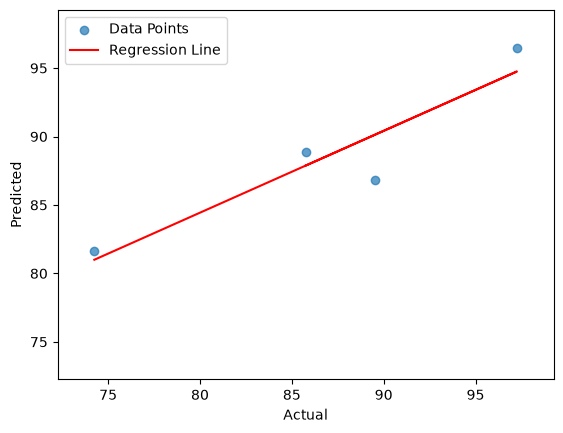

In [139]:
# Gives data arrays
x = comparison_tbl['Actual']
y = comparison_tbl['Predicted']

# Calculates the regression line
#fits a polynomial curve to data points using the Least Squares method(finds a line that minimizes the sqd dist b/w real dots and the line itself
slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

plt.scatter(x, y, alpha=0.7, label='Data Points')
plt.plot(x, trendline, color='red', label='Regression Line')  # Line plot

# min and max limits from actual values of x and y 

min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())

# to make both axes share exact same minimum and maximum 
# (-2, +2 to add a buffer along the axis lines)

plt.xlim(min_val-2, max_val+2)
plt.ylim(min_val-2, max_val+2)

plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.legend()
plt.show()
